# Entrenamiento de Modelos — Predicción de Dengue## Universidad de El Salvador  Ingeniería En Sistemas Informaticos.
Este notebook entrena y compara **tres modelos** de forma escalonada (de lo simple a lo complejo):1. **Regresión Lineal** — modelo base interpretable2. **Random Forest** — modelo de árboles robusto3. **XGBoost** — gradient boosting, típicamente el más preciso**Metodología clave:**- División cronológica: Train (2015-2021), Validación (2022), Prueba (2023)- Sin fuga de datos: no se usan columnas objetivo redundantes ni el año como predictor- Métricas para conteos: MAE, RMSE, y R²- Comparación contra un baseline ingenuo (predecir el valor de la semana anterior)


## 1. Instalación e importación de librerías

In [1]:
# XGBoost ya viene normalmente en Colab;
# !pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
print('Librerías cargadas')

Librerías cargadas


## 2. Carga de datos desde GitHubLos archivos se leen directamente desde el repositorio. Usamos las URLs `raw`.

In [2]:
BASE = 'https://raw.githubusercontent.com/Melvillalta1/DengueSV/refs/heads/main/'

train = pd.read_csv(BASE + 'dataset_train.csv')
val   = pd.read_csv(BASE + 'dataset_val.csv')
test  = pd.read_csv(BASE + 'dataset_test.csv')
deptos = pd.read_csv(BASE + 'tabla%20departamentos.csv')

print(f'Train: {train.shape}')
print(f'Val:   {val.shape}')
print(f'Test:  {test.shape}')
print(f'Departamentos: {deptos.shape}')
deptos.head()

Train: (4233, 45)
Val:   (472, 45)
Test:  (312, 45)
Departamentos: (14, 2)


,id,departamento
0,1,Morazan
1,2,Ahuachapan
2,3,Chalatenango
3,4,Santa Ana
4,5,San Miguel


## 3. Integrar el ID de departamentoConvertimos el nombre del departamento (texto) a su ID numérico usando la tabla,para que los modelos puedan usarlo como variable.

In [3]:
def agregar_id_depto(df, tabla_deptos):
    return df.merge(tabla_deptos, on='departamento', how='left')

train = agregar_id_depto(train, deptos)
val   = agregar_id_depto(val, deptos)
test  = agregar_id_depto(test, deptos)

# Verificar que todos los departamentos encontraron su id
print('Nulos en id tras merge:')
print(f'  Train: {train["id"].isna().sum()}')
print(f'  Val:   {val["id"].isna().sum()}')
print(f'  Test:  {test["id"].isna().sum()}')
train[['departamento','id']].drop_duplicates().head()

Nulos en id tras merge:
  Train: 0
  Val:   0
  Test:  0


,departamento,id
0,Ahuachapan,2
292,Cabañas,13
578,Chalatenango,3
870,Cuscatlan,12
1178,La Libertad,9


## 4. Selección de variables (evitar fuga de datos)Esta es una parte crítica. Definimos qué columnas son predictoras y cuál es el objetivo.**Se excluyen de las predictoras:**- `casos_confirmados`, `casos_probables`: son parte de `casos_total` (fuga de objetivo)- `casos_total`: es el objetivo, no un predictor- `anio_epi`: evita que el modelo memorice años en vez de aprender condiciones- `departamento`: es texto; usamos su `id` numérico en su lugar

In [4]:
OBJETIVO = 'casos_total'

# Columnas que NO son predictoras
excluir = ['casos_confirmados', 'casos_probables', 'casos_total',
           'anio_epi', 'departamento']

# Predictoras = todas las demás
predictoras = [c for c in train.columns if c not in excluir]

print(f'Variable objetivo: {OBJETIVO}')
print(f'\nNúmero de predictoras: {len(predictoras)}')
print('Predictoras:')
for p in predictoras:
    print(f'  - {p}')

Variable objetivo: casos_total

Número de predictoras: 41
Predictoras:
  - semana_epi
  - t2m_max_sem
  - t2m_min_sem
  - t2m_prom_sem
  - precip_total
  - precip_dias_lluvia
  - humedad_prom
  - viento_prom
  - t2m_prom_sem_lag1
  - t2m_prom_sem_lag2
  - t2m_prom_sem_lag3
  - t2m_prom_sem_lag4
  - precip_total_lag1
  - precip_total_lag2
  - precip_total_lag3
  - precip_total_lag4
  - humedad_prom_lag1
  - humedad_prom_lag2
  - humedad_prom_lag3
  - humedad_prom_lag4
  - t2m_max_sem_lag1
  - t2m_max_sem_lag2
  - t2m_max_sem_lag3
  - t2m_max_sem_lag4
  - amplitud_termica
  - grados_dia
  - en_rango_optimo
  - temp_bajo_letal_frio
  - temp_sobre_estres_calor
  - dist_temp_optima
  - semana_lluviosa
  - estacion_lluviosa
  - semana_sin
  - semana_cos
  - casos_total_lag1
  - casos_total_lag2
  - casos_total_lag3
  - casos_total_lag4
  - casos_tendencia
  - casos_promedio_4sem
  - id


## 5. Preparar X e y, y manejar valores nulosLos rezagos tienen nulos en las primeras semanas de cada departamento.Los eliminamos SOLO del entrenamiento (no imputamos con datos de otros conjuntos).

In [5]:
def preparar(df, predictoras, objetivo):
    X = df[predictoras].copy()
    y = df[objetivo].copy()
    return X, y

X_train, y_train = preparar(train, predictoras, OBJETIVO)
X_val,   y_val   = preparar(val, predictoras, OBJETIVO)
X_test,  y_test  = preparar(test, predictoras, OBJETIVO)

# Eliminar filas con nulos en los rezagos (primeras semanas de cada depto)
mask_train = X_train.notna().all(axis=1)
X_train, y_train = X_train[mask_train], y_train[mask_train]

# Para val y test, rellenar nulos residuales con 0 (no deberían tener muchos)
X_val = X_val.fillna(0)
X_test = X_test.fillna(0)

print(f'Train tras limpiar nulos: {X_train.shape}')
print(f'Val:  {X_val.shape}')
print(f'Test: {X_test.shape}')

Train tras limpiar nulos: (4177, 41)
Val:  (472, 41)
Test: (312, 41)


## 6. Modelo base (baseline)Antes de los modelos, establecemos una referencia: predecir que esta semanatendrá los mismos casos que la semana anterior (`casos_total_lag1`).Si un modelo no supera esto, no aporta valor.

In [6]:
# Baseline: usar casos_total_lag1 como predicción
def evaluar(y_true, y_pred, nombre):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'{nombre:20s} | MAE: {mae:6.3f} | RMSE: {rmse:6.3f} | R2: {r2:6.3f}')
    return {'modelo': nombre, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

resultados = []

# Baseline sobre el conjunto de prueba
baseline_pred = test['casos_total_lag1'].fillna(0).values
print('=== BASELINE (predecir = semana anterior) ===')
resultados.append(evaluar(y_test, baseline_pred, 'Baseline (lag1)'))

=== BASELINE (predecir = semana anterior) ===
Baseline (lag1)      | MAE:  0.631 | RMSE:  2.082 | R2: -1.061


## 7. Modelo 1 — Regresión LinealEl modelo más simple e interpretable. Sirve como referencia estadística.

In [7]:
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

pred_lr_val  = modelo_lr.predict(X_val)
pred_lr_test = modelo_lr.predict(X_test)

# Las predicciones negativas no tienen sentido (no hay casos negativos)
pred_lr_test = np.clip(pred_lr_test, 0, None)

print('=== REGRESIÓN LINEAL ===')
print('Validación:')
evaluar(y_val, np.clip(pred_lr_val, 0, None), 'Reg. Lineal (val)')
print('Prueba:')
resultados.append(evaluar(y_test, pred_lr_test, 'Regresión Lineal'))

=== REGRESIÓN LINEAL ===
Validación:
Reg. Lineal (val)    | MAE:  0.730 | RMSE:  1.366 | R2: -1.278
Prueba:
Regresión Lineal     | MAE:  0.945 | RMSE:  2.009 | R2: -0.919


In [8]:
# Coeficientes de la regresión (interpretabilidad)
coefs = pd.DataFrame({
    'variable': predictoras,
    'coeficiente': modelo_lr.coef_
}).sort_values('coeficiente', key=abs, ascending=False)

print('Top 10 variables más influyentes (Regresión Lineal):')
print(coefs.head(10).to_string(index=False))

Top 10 variables más influyentes (Regresión Lineal):
               variable  coeficiente
             semana_cos    -1.419719
             semana_sin    -0.842649
temp_sobre_estres_calor    -0.644815
        en_rango_optimo    -0.618684
        semana_lluviosa    -0.604502
       casos_total_lag1     0.535836
       t2m_max_sem_lag1    -0.436477
       dist_temp_optima     0.339818
       casos_total_lag2     0.313164
       t2m_max_sem_lag2     0.294108


## 8. Modelo 2 — Random ForestModelo de árboles robusto que captura relaciones no lineales.

In [9]:
modelo_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)
modelo_rf.fit(X_train, y_train)

pred_rf_val  = modelo_rf.predict(X_val)
pred_rf_test = modelo_rf.predict(X_test)

print('=== RANDOM FOREST ===')
print('Validación:')
evaluar(y_val, pred_rf_val, 'Random Forest (val)')
print('Prueba:')
resultados.append(evaluar(y_test, pred_rf_test, 'Random Forest'))

=== RANDOM FOREST ===
Validación:
Random Forest (val)  | MAE:  0.485 | RMSE:  1.146 | R2: -0.603
Prueba:
Random Forest        | MAE:  0.572 | RMSE:  1.591 | R2: -0.202


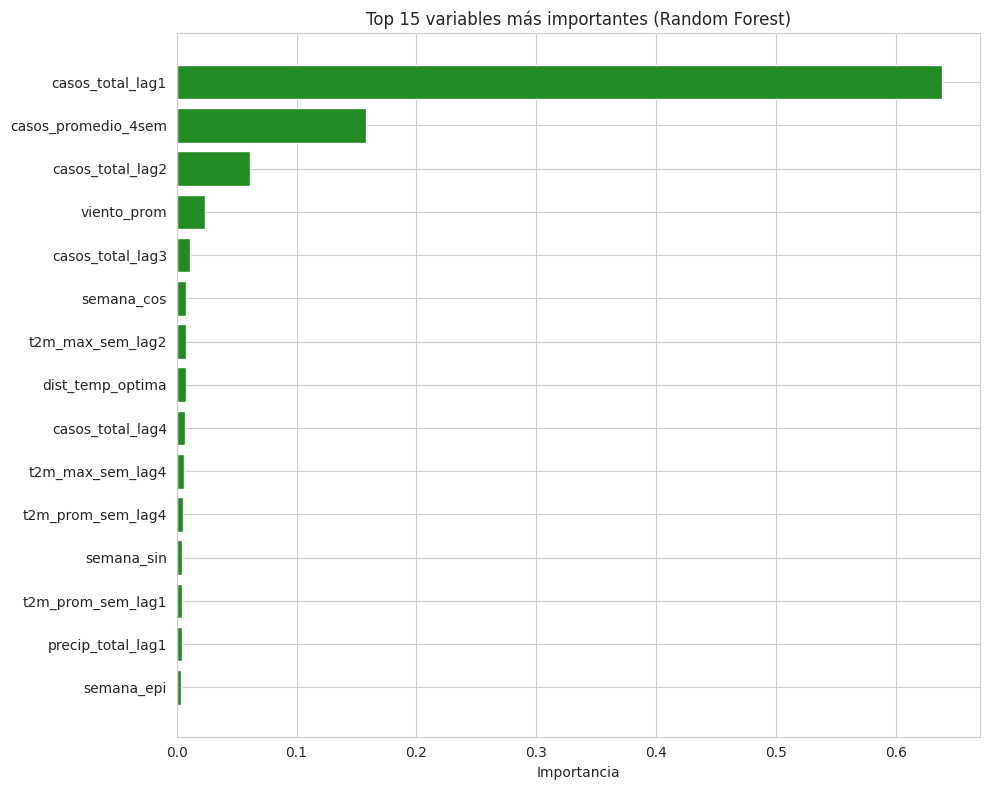

           variable  importancia
   casos_total_lag1     0.638131
casos_promedio_4sem     0.158175
   casos_total_lag2     0.060788
        viento_prom     0.023298
   casos_total_lag3     0.011305
         semana_cos     0.007815
   t2m_max_sem_lag2     0.007562
   dist_temp_optima     0.007434
   casos_total_lag4     0.006531
   t2m_max_sem_lag4     0.006283


In [10]:
# Importancia de variables (Random Forest)
imp_rf = pd.DataFrame({
    'variable': predictoras,
    'importancia': modelo_rf.feature_importances_
}).sort_values('importancia', ascending=False)

plt.figure(figsize=(10, 8))
top15 = imp_rf.head(15)
plt.barh(top15['variable'], top15['importancia'], color='forestgreen')
plt.xlabel('Importancia')
plt.title('Top 15 variables más importantes (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(imp_rf.head(10).to_string(index=False))

## 9. Modelo 3 — XGBoostGradient boosting, típicamente el más preciso para datos tabulares.

In [11]:
modelo_xgb = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
modelo_xgb.fit(X_train, y_train,
               eval_set=[(X_val, y_val)],
               verbose=False)

pred_xgb_val  = modelo_xgb.predict(X_val)
pred_xgb_test = modelo_xgb.predict(X_test)
pred_xgb_test = np.clip(pred_xgb_test, 0, None)

print('=== XGBOOST ===')
print('Validación:')
evaluar(y_val, np.clip(pred_xgb_val, 0, None), 'XGBoost (val)')
print('Prueba:')
resultados.append(evaluar(y_test, pred_xgb_test, 'XGBoost'))

=== XGBOOST ===
Validación:
XGBoost (val)        | MAE:  0.525 | RMSE:  1.256 | R2: -0.926
Prueba:
XGBoost              | MAE:  0.663 | RMSE:  1.995 | R2: -0.891


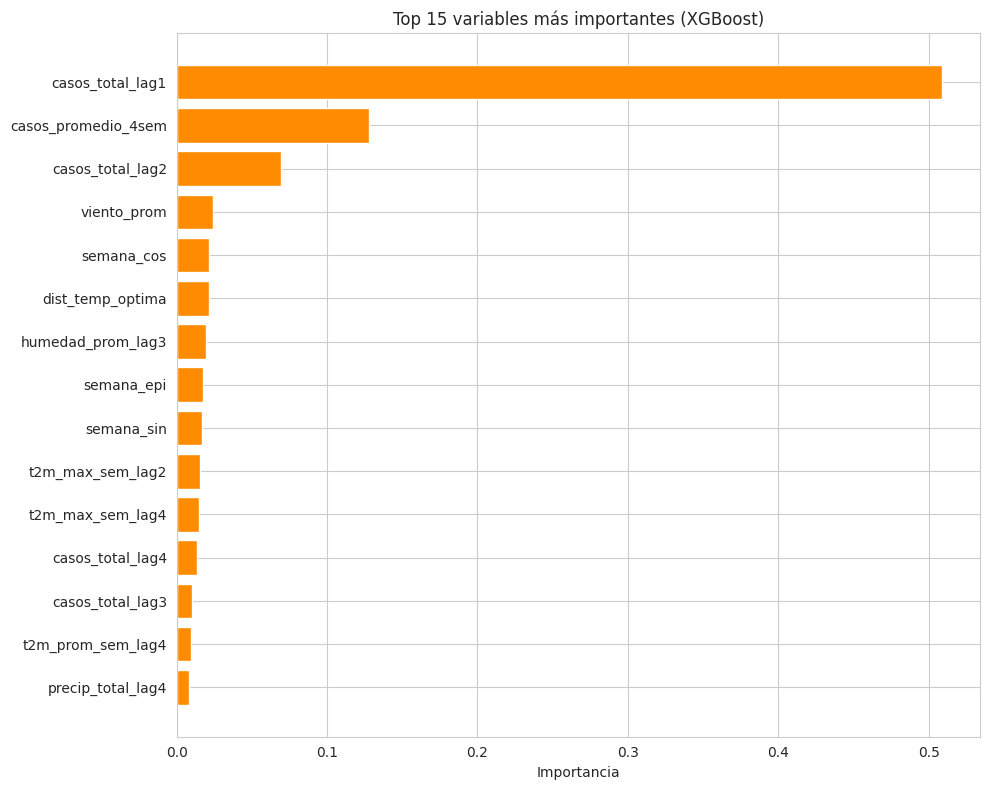

           variable  importancia
   casos_total_lag1     0.508713
casos_promedio_4sem     0.127596
   casos_total_lag2     0.069200
        viento_prom     0.023897
         semana_cos     0.021413
   dist_temp_optima     0.021358
  humedad_prom_lag3     0.019774
         semana_epi     0.017389
         semana_sin     0.016646
   t2m_max_sem_lag2     0.015384


In [12]:
# Importancia de variables (XGBoost)
imp_xgb = pd.DataFrame({
    'variable': predictoras,
    'importancia': modelo_xgb.feature_importances_
}).sort_values('importancia', ascending=False)

plt.figure(figsize=(10, 8))
top15 = imp_xgb.head(15)
plt.barh(top15['variable'], top15['importancia'], color='darkorange')
plt.xlabel('Importancia')
plt.title('Top 15 variables más importantes (XGBoost)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(imp_xgb.head(10).to_string(index=False))

## 10. Comparación de los modelos

=== COMPARACIÓN FINAL (sobre conjunto de PRUEBA 2023) ===

          modelo      MAE     RMSE        R2
 Baseline (lag1) 0.631410 2.082436 -1.060567
Regresión Lineal 0.944828 2.009397 -0.918559
   Random Forest 0.571829 1.590624 -0.202205
         XGBoost 0.662983 1.995043 -0.891245


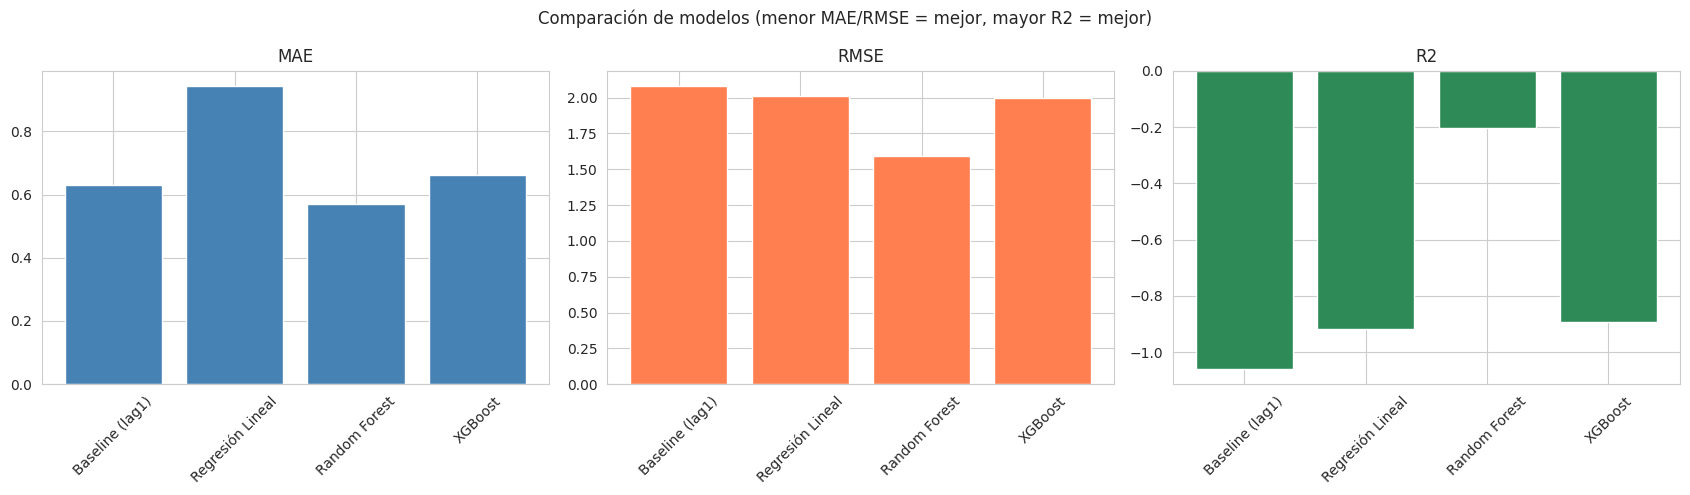

In [13]:
comparacion = pd.DataFrame(resultados)
print('=== COMPARACIÓN FINAL (sobre conjunto de PRUEBA 2023) ===\n')
print(comparacion.to_string(index=False))

# Gráfico comparativo
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, metrica, color in zip(axes, ['MAE', 'RMSE', 'R2'], ['steelblue','coral','seagreen']):
    ax.bar(comparacion['modelo'], comparacion[metrica], color=color)
    ax.set_title(metrica)
    ax.tick_params(axis='x', rotation=45)
    ax.axhline(0, color='black', linewidth=0.5)
plt.suptitle('Comparación de modelos (menor MAE/RMSE = mejor, mayor R2 = mejor)')
plt.tight_layout()
plt.show()

## 11. Predicciones vs realidad (mejor modelo)

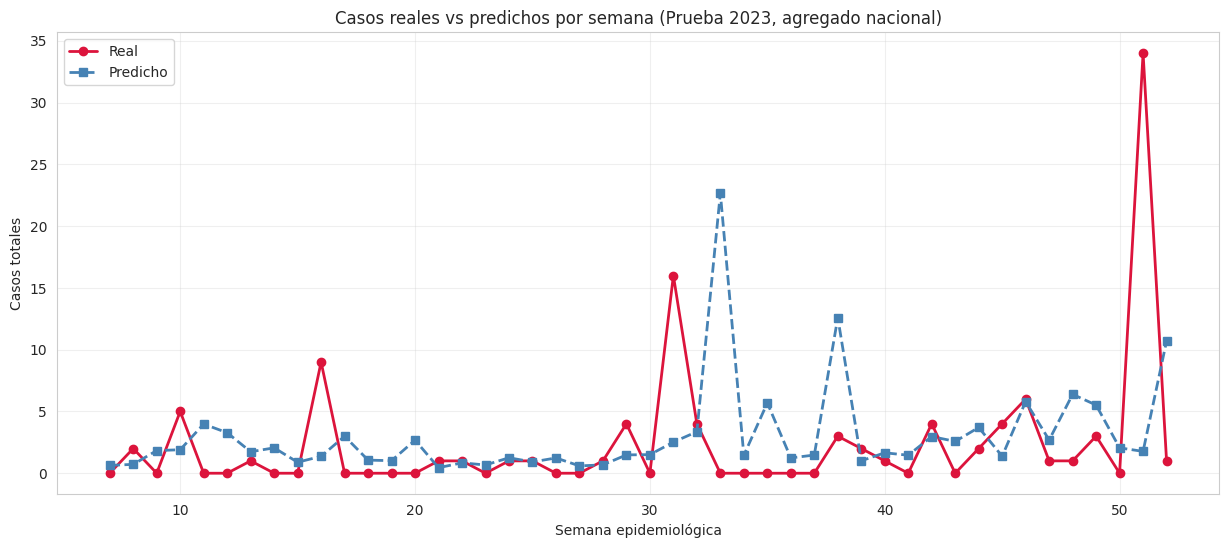

In [14]:
# Graficar predicciones vs valores reales en el conjunto de prueba
# Ajusta 'pred_final' al modelo que resultó mejor
pred_final = pred_xgb_test  # cambia a pred_rf_test o pred_lr_test según resultados

test_plot = test.copy()
test_plot['prediccion'] = pred_final

# Agregado nacional por semana
comp_semana = test_plot.groupby('semana_epi').agg(
    real=('casos_total','sum'),
    predicho=('prediccion','sum')
).reset_index()

plt.figure(figsize=(15, 6))
plt.plot(comp_semana['semana_epi'], comp_semana['real'], marker='o',
         label='Real', color='crimson', linewidth=2)
plt.plot(comp_semana['semana_epi'], comp_semana['predicho'], marker='s',
         label='Predicho', color='steelblue', linewidth=2, linestyle='--')
plt.title('Casos reales vs predichos por semana (Prueba 2023, agregado nacional)')
plt.xlabel('Semana epidemiológica')
plt.ylabel('Casos totales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 12. ConclusionesDocumenta aquí (completar con los resultados):### Desempeño de los modelos| Modelo | MAE | RMSE | R² | ¿Supera baseline? ||--------|-----|------|-----|-------------------|| Baseline (lag1) | ___ | ___ | ___ | — || Regresión Lineal | ___ | ___ | ___ | ___ || Random Forest | ___ | ___ | ___ | ___ || XGBoost | ___ | ___ | ___ | ___ |### Hallazgos- **Mejor modelo:** _____- **Variables más importantes:** _(¿coinciden con lo esperado del EDA? Los rezagos de casos deberían dominar)_- **¿Los modelos superan el baseline ingenuo?:** _____### Consideraciones importantes- Los conjuntos de validación y prueba (2022-2023) son años de BAJA transmisión.  El modelo se evalúa principalmente en su capacidad de predecir años tranquilos.- Para una evaluación más completa de años epidémicos, se necesitarían más años  con brotes en el conjunto de prueba.### Próximos pasos1. Ajuste de hiperparámetros del mejor modelo2. Considerar transformación de la variable objetivo (ej. log) por el sesgo3. Incorporar datos de población para predecir tasas de incidencia4. Evaluar el modelo específicamente en su capacidad de detectar inicios de brote